In [1]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import sys
import os

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))

from functions.tools import configure_notebook_display, load_raw_datasets

configure_notebook_display()

In [2]:
# ============================================================
# LOADING DATA
# ============================================================

df_meta, df_readings = load_raw_datasets()

In [3]:
# ============================================================
# DATE PARSING
# ============================================================

df_readings["parsed_date"] = pd.to_datetime(
    df_readings["date"],
    format="mixed",
    dayfirst=True)

df_meta["parsed_sowing_date"] = pd.to_datetime(
    df_meta["sowing_date"])

In [4]:
# ============================================================
# SENSOR STATUS STANDARDIZATION (Preprocessing step done here to analyse only)
# ============================================================

df_readings["sensor_status_clean"] = (
    df_readings["sensor_status"]
    .astype(str)
    .str.strip()
    .str.lower())

print(df_readings['sensor_status_clean'].value_counts())

sensor_status_clean
ok       3064
error     246
Name: count, dtype: int64


In the earlier analysis, all physically invalid NDVI values were found to occur alongside erroneous or non-OK sensor states. However, since the total number of non-OK sensor states (246) is higher than the count of invalid NDVI values (104), not every degraded sensor state necessarily results in an invalid NDVI reading.

In [5]:
# ============================================================
# VALID NDVI FILTER
# ============================================================

valid_ndvi_df = df_readings[
    (df_readings["ndvi_value"] >= -1) &
    (df_readings["ndvi_value"] <= 1)
    ].copy()

count    3343.000000
mean        0.477412
std         0.214871
min        -0.060000
25%         0.285000
50%         0.502000
75%         0.647500
max         0.954000
Name: ndvi_value, dtype: float64

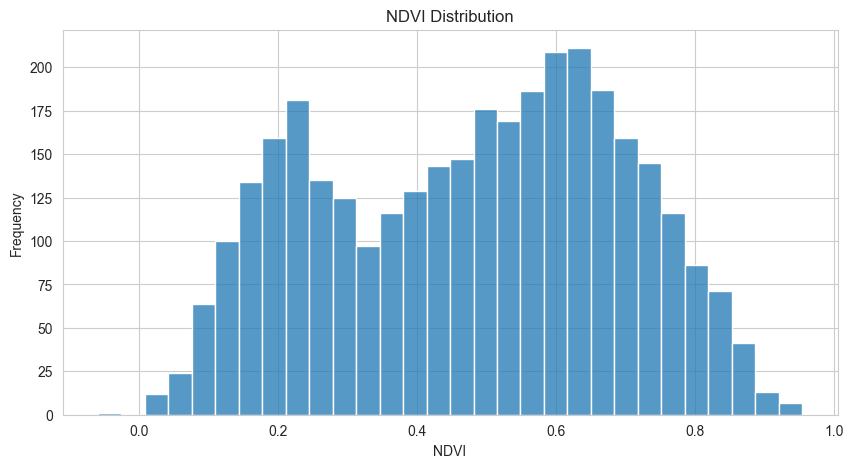

In [6]:
# ============================================================
# NDVI DISTRIBUTION
# ============================================================

display(
    valid_ndvi_df["ndvi_value"]
    .describe())

sns.histplot(
    valid_ndvi_df["ndvi_value"],
    bins=30)

plt.title("NDVI Distribution")
plt.xlabel("NDVI")
plt.ylabel("Frequency")

plt.show()

The NDVI distribution is looking fairly natural after filtering out the physically invalid readings. Most values are clustering around moderate vegetation levels instead of concentrating near extreme boundaries.

This increase the confidence in the validd NDVI signal where earlier we had little doubt.

count    3343.000000
mean       25.390996
std         5.750621
min        15.100000
25%        20.600000
50%        25.400000
75%        30.400000
max        35.500000
Name: temperature_c, dtype: float64

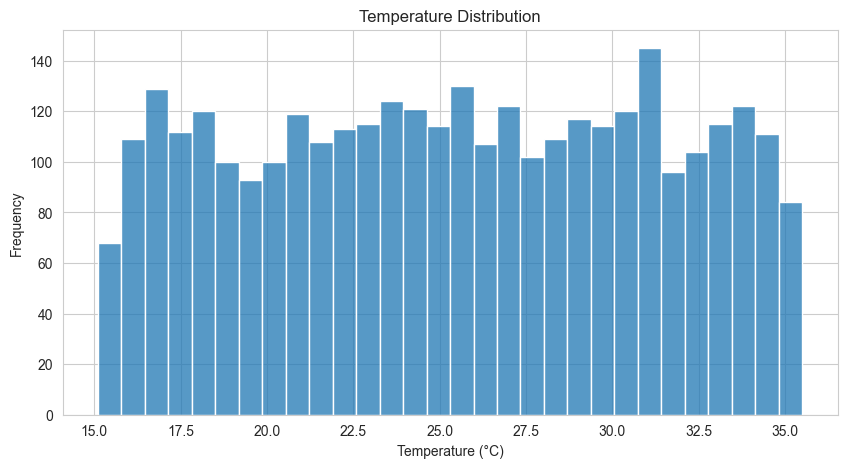

In [7]:
# ============================================================
# TEMPERATURE DISTRIBUTION
# ============================================================

display(
    valid_ndvi_df["temperature_c"]
    .describe())

sns.histplot(
    valid_ndvi_df["temperature_c"],
    bins=30)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

Temperature values are showing a smooth and realistic spread without extreme spikes or suspicious clustering. The range is staying operationally believable and continues looking much cleaner than the NDVI sensing layer.

As in the previous analysis and here as well, temperature appears to be one of the more reliable variables in the dataset.

count    3343.000000
mean        0.837033
std         2.054307
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        15.800000
Name: rainfall_mm, dtype: float64

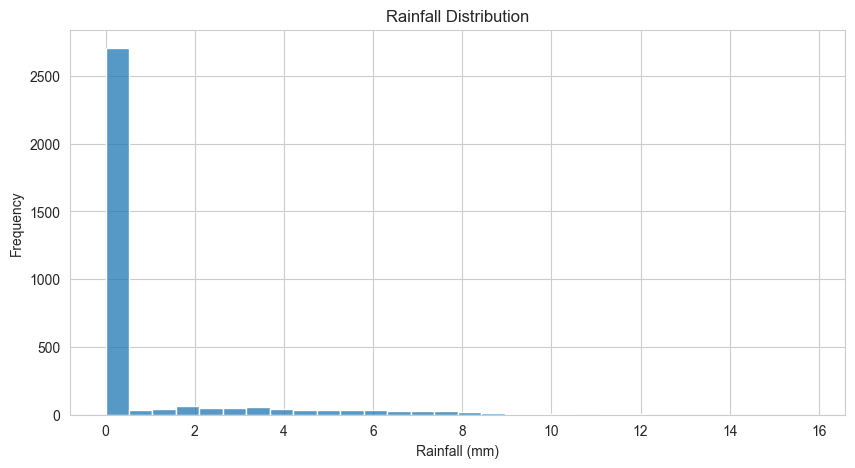

In [8]:
# ============================================================
# RAINFALL DISTRIBUTION
# ============================================================

display(
    valid_ndvi_df["rainfall_mm"]
    .describe())

sns.histplot(
    valid_ndvi_df["rainfall_mm"],
    bins=30)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

Rainfall is heavily concentrated around low or zero values, with fewer high-rainfall observations appearing across the dataset.

This could simply reflect off monsoon season, we can conclude this as the time period of the readdings is from jan to may which is off mild winter and peak summer season. Nothing operationally unrealistic is standing out so far.

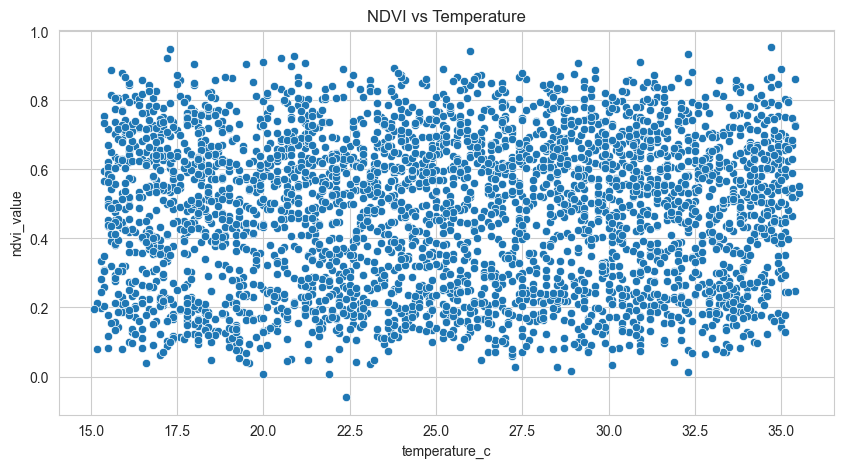

In [9]:
# ============================================================
# NDVI vs TEMPERATURE
# ============================================================

sns.scatterplot(
    data=valid_ndvi_df,
    x="temperature_c",
    y="ndvi_value")

plt.title("NDVI vs Temperature")

plt.show()

The relationship between NDVI and temperature is not showing any obvious contradictory behavior. Higher and lower NDVI values are spreading across a realistic temperature range.

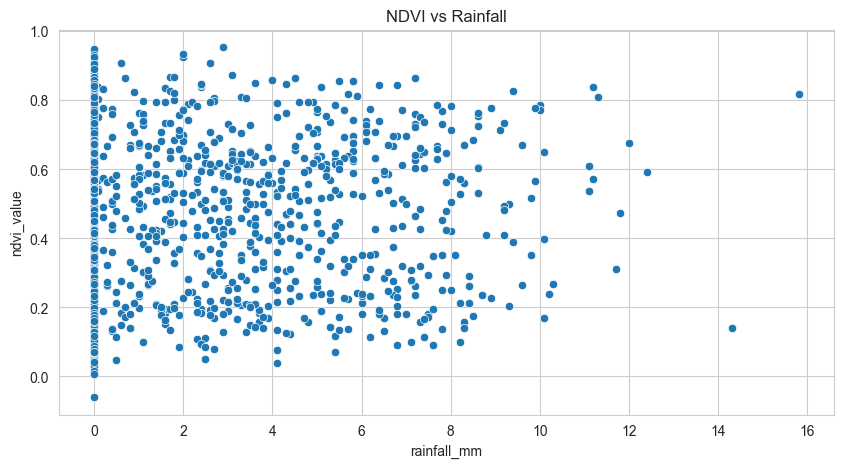

In [10]:
# ============================================================
# NDVI vs RAINFALL
# ============================================================

sns.scatterplot(
    data=valid_ndvi_df,
    x="rainfall_mm",
    y="ndvi_value")

plt.title("NDVI vs Rainfall")

plt.show()

The relationship between rainfall and NDVI appears relatively noisy, but not unrealistic. Since rainfall values themselves are mostly concentrated around lower levels, a weaker visual relationship was expected here.

In [11]:
# ============================================================
# MERGE DATASETS (Only for analysis)
# ============================================================

merged_df = valid_ndvi_df.merge(
    df_meta,
    on="parcel_id",
    how="left")

In [12]:
# ============================================================
# CROP-WISE NDVI BEHAVIOR
# ============================================================

crop_ndvi_summary = (
    merged_df
    .groupby("crop_type")["ndvi_value"]
    .agg(["mean", "median", "std", "count"])
    .reset_index())

display(crop_ndvi_summary)

,crop_type,mean,median,std,count
0,soybean,0.398682,0.4350,0.175563,528
1,sugarcane,0.505071,0.5395,0.217231,2514
2,wheat,0.384483,0.3900,0.195220,261


The crop-level NDVI behavior is looking biologically believable. Sugarcane is showing higher average vegetation intensity compared to soybean and wheat, which aligns with expectations for denser crop growth.

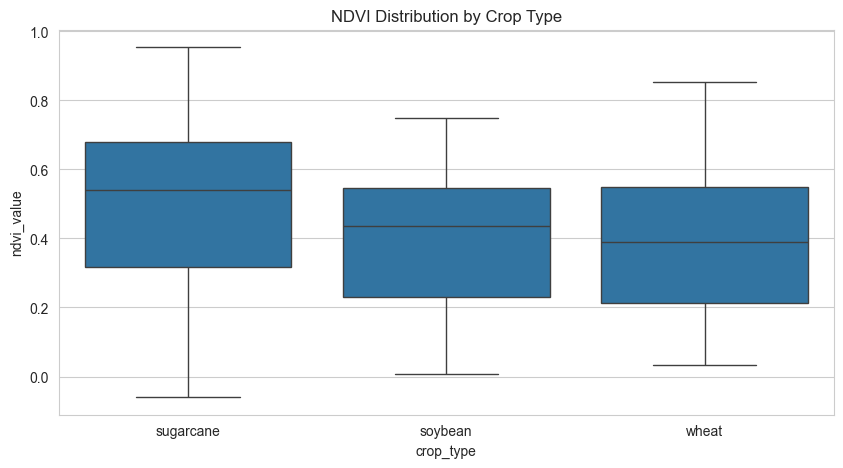

In [13]:
# ============================================================
# NDVI DISTRIBUTION BY CROP
# ============================================================

sns.boxplot(
    data=merged_df,
    x="crop_type",
    y="ndvi_value")

plt.title("NDVI Distribution by Crop Type")

plt.show()

The crop-wise NDVI distributions are showing noticeable variation between crop categories without appearing noisy.

In [14]:
# ============================================================
# SENSOR STATUS vs NDVI
# ============================================================

status_ndvi_summary = (
    merged_df
    .groupby("sensor_status_clean")["ndvi_value"]
    .agg(["mean", "median", "std", "count"])
    .reset_index())

display(status_ndvi_summary)

,sensor_status_clean,mean,median,std,count
0,error,0.512599,0.5445,0.213721,142
1,ok,0.476158,0.5000,0.214918,3064


Even after removing invalid NDVI values, degraded sensor states are still producing many reasonable vegetation readings instead of only corrupted measurements.

This is an important finding because it suggests sensor degradation is not behaving in a purely binary way. Non-OK statuses may still contain usable information depending on the context. Which is what to do when NVDI is valid and sensor reading is error.

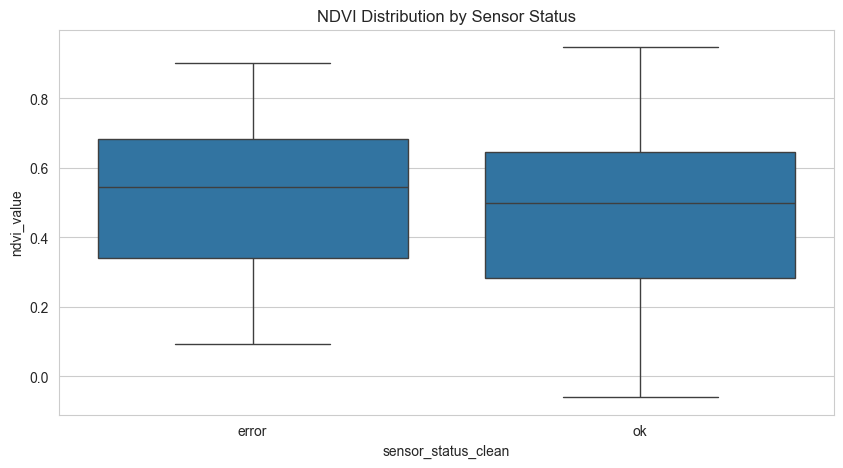

In [15]:
# ============================================================
# NDVI DISTRIBUTION BY SENSOR STATUS
# ============================================================

sns.boxplot(
    data=merged_df,
    x="sensor_status_clean",
    y="ndvi_value")

plt.title("NDVI Distribution by Sensor Status")

plt.show()

The NDVI spread across sensor states is remaining relatively comparable.

In [17]:
# Updated tracker from notebook 03
issue_tracker = pd.DataFrame({

    "column": [
        "parcel_id",
        "crop_type",
        "sowing_date",
        "date",
        "ndvi_value",
        "sensor_status",
        "parcel_id",
        "parcel_id",
        
    ],

    "issue_identified": [
        "Parcel inconsistency between metadata and readings",
        "Imbalanced crop distribution",
        "Stored as string instead of datetime",
        "Multiple date formats within the same column",
        "NDVI values outside valid biological range [-1, 1]",
        "Dirty categorical labels and missing statuses",
        "Incomplete parcel coverage",
        "Temporal continuity gaps"

    ],

    "prevalence": [
        "3 parcels absent in readings and 2 absent in metadata",
        "Sugarcane dominates by ~ 70% of all parcels",
        "Entire column",
        "3 types of formats detected",
        "104 invalid records detected",
        "Whitespace, casing issues and 137 missing values detected",
        "Parcel 098 and 099 show only 20 record counts, while other have ~130",
        "Large temporal gaps for parcel 098 and 099, 90 and 63 resp"
    ],

    "severity": [
        "High",
        "Low",
        "Medium",
        "High",
        "High",
        "Medium",
        "High",
        "Medium"

    ],

        "requires_processing_for_final_analysis": [
        "Yes",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Maybe",
        "Maybe"
    ]
})

display(issue_tracker)

,column,issue_identified,prevalence,severity,requires_processing_for_final_analysis
0,parcel_id,Parcel inconsistency between metadata and readings,3 parcels absent in readings and 2 absent in metadata,High,Yes
1,crop_type,Imbalanced crop distribution,Sugarcane dominates by ~ 70% of all parcels,Low,No
2,sowing_date,Stored as string instead of datetime,Entire column,Medium,Yes
3,date,Multiple date formats within the same column,3 types of formats detected,High,Yes
4,ndvi_value,"NDVI values outside valid biological range [-1, 1]",104 invalid records detected,High,Yes
5,sensor_status,Dirty categorical labels and missing statuses,"Whitespace, casing issues and 137 missing values detected",Medium,Yes
6,parcel_id,Incomplete parcel coverage,"Parcel 098 and 099 show only 20 record counts, while other have ~130",High,Maybe
7,parcel_id,Temporal continuity gaps,"Large temporal gaps for parcel 098 and 099, 90 and 63 resp",Medium,Maybe
